# Notebook 10: Validation of Recursive Future Demand Forecasting – Final Conclusion

## Overview

This notebook focused on validating the real-world forecasting capability of the selected XGBoost model by performing recursive multi-step demand forecasting on an unseen validation dataset. Unlike traditional model evaluation, this notebook simulated a realistic forecasting scenario where future demand values are unknown and must be predicted sequentially using previously generated forecasts.

---

## Key Tasks Performed

### 1. Loaded the Final Selected Model

- Loaded the best-performing XGBoost model selected during model comparison and evaluation.
- Ensured the forecasting framework used the same model chosen as the final project model.

### 2. Selected the Forecasting Zone

- Identified the zone with the highest number of observations.
- Chose this zone to ensure sufficient historical demand information for reliable recursive forecasting.

### 3. Created Time-Based Validation Split

- Used chronological splitting to preserve temporal order.
- Training data consisted of the first 24 days.
- Validation data consisted of the following 3 days (72 hours).
- Test data remained untouched for future evaluation purposes.

### 4. Prepared Historical Demand Series

- Extracted historical demand observations from the training period.
- Used these observations to initialize recursive forecasting features.

### 5. Performed Recursive Multi-Step Forecasting

- Forecasted demand for all 72 validation hours.
- Generated lag features dynamically using previous predictions.
- Simulated a realistic future forecasting environment where actual future demand values are unavailable.
- Used lag features and rolling statistics to create forecasting inputs at each step.

### 6. Generated Validation Forecast Dataset

- Combined actual demand and forecasted demand into a single comparison dataset.
- Calculated residuals to measure forecasting errors.

### 7. Evaluated Forecast Accuracy

The forecasting model achieved:

| Metric | Value |
|----------|----------|
| MAE | 91.87 |
| RMSE | 121.27 |

These metrics quantified the model's performance over the entire 72-hour forecasting horizon.

### 8. Visualized Actual vs Forecasted Demand

- Compared actual demand against forecasted demand using line plots.
- Evaluated the model's ability to capture temporal demand patterns.
- Identified areas where forecasting performance deviated from actual observations.

### 9. Analyzed Forecasting Behavior

The validation analysis revealed:

- Successful capture of overall demand trends.
- Identification of major demand peaks and low-demand periods.
- Increasing forecast error as the forecasting horizon extended.
- Consistent overestimation of demand during several validation periods.

---

## Major Findings

### Successful Outcomes

- The XGBoost model successfully learned important temporal demand patterns.
- Hourly demand seasonality was captured effectively.
- The recursive forecasting framework operated correctly across the full validation horizon.
- The model demonstrated the ability to forecast future demand without access to future observations.

### Identified Challenges

Several factors contributed to forecasting errors:

- Limited historical training data (one month only).
- Recursive forecasting error propagation.
- High variability in taxi demand patterns.
- Limited weekly seasonal information.
- Absence of external variables such as weather and events.
- Increased uncertainty associated with long-horizon forecasting.

---

## Practical Significance

This notebook provided a realistic assessment of how the forecasting system would behave in a production environment.

Unlike standard validation approaches that use actual lag values, this notebook evaluated the model under true forecasting conditions where future observations are unavailable.

As a result, the notebook served as an important validation of the complete forecasting pipeline and highlighted both its capabilities and limitations.

---

## Final Conclusion

The recursive forecasting framework successfully generated 72-hour future demand forecasts using the selected XGBoost model. The model effectively captured the overall demand structure and temporal behavior of taxi demand, demonstrating its ability to learn meaningful forecasting patterns from historical observations.

Although forecasting accuracy decreased over longer horizons due to recursive error propagation and demand variability, the experiment provided a realistic simulation of real-world forecasting conditions. The results confirmed that the forecasting pipeline is technically sound and capable of producing future demand estimates while also revealing the challenges associated with long-term demand prediction.

Overall, this notebook successfully validated the end-to-end future demand forecasting workflow and completed the final stage of the NYC Taxi Demand Forecasting project.

---
---

# Validation Future Demand Forecasting

## Purpose

Evaluate the recursive forecasting capability of the final XGBoost model by forecasting the next 72 hours using the validation dataset.

---

## Why are we doing this?

Traditional model evaluation provides one-step predictions.

However, future forecasting requires recursive predictions where previous forecasts become inputs for subsequent forecasts.

Therefore, validating the recursive forecasting pipeline before deployment is essential.

---

## Objectives

- Forecast demand for the validation period (72 hours).
- Compare forecasts with actual demand.
- Evaluate recursive forecasting performance.
- Assess deployment readiness.

---

## Expected Outcome

A reliable recursive forecasting framework suitable for future taxi demand forecasting.

---

# Validation Future Demand Forecasting

## Purpose

Evaluate the recursive forecasting capability of the final XGBoost model by forecasting the next 72 hours using the validation dataset.

---

## Why are we doing this?

Traditional model evaluation provides one-step predictions.

However, future forecasting requires recursive predictions where previous forecasts become inputs for subsequent forecasts.

Therefore, validating the recursive forecasting pipeline before deployment is essential.

---

## Objectives

- Forecast demand for the validation period (72 hours).
- Compare forecasts with actual demand.
- Evaluate recursive forecasting performance.
- Assess deployment readiness.

---

## Expected Outcome

A reliable recursive forecasting framework suitable for future taxi demand forecasting.

In [7]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

print("Libraries imported successfully.")

Libraries imported successfully.


# Step 2:Load Final XGBoost Model

Load the best-performing XGBoost model selected during model comparison.

In [8]:
model = joblib.load(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/Yellow_Dataset/models/xgboost_model.pkl"
)

print("Model loaded successfully.")

Model loaded successfully.


In [9]:
df = pd.read_parquet(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/Yellow_Dataset/data/feature_engineered_demand.parquet"
)

print(
    "Dataset Shape:",
    df.shape
)

Dataset Shape: (84740, 14)


# Select Forecasting Zone

Forecasting is performed at the zone level.

The zone with the largest number of observations is selected to ensure sufficient historical information for recursive forecasting.

In [10]:
zone_counts = (
    df.groupby("PULocationID")
    .size()
    .sort_values(ascending=False)
)

zone_id = zone_counts.index[0]

print(
    "Selected Zone:",
    zone_id
)

print(
    "Total Observations:",
    zone_counts.iloc[0]
)

Selected Zone: 79
Total Observations: 577


## Why Was Only One Zone Selected for Forecasting?

- The primary objective of this notebook was to **validate the recursive forecasting framework**, rather than develop a full production-level forecasting system for all NYC zones.

- A **single representative zone** was selected to evaluate whether the forecasting pipeline could successfully generate multi-step future demand predictions under realistic conditions.

- Forecasting multiple zones simultaneously would substantially increase **computational complexity**, as recursive forecasting would need to be performed independently for each zone and each forecasting horizon.

- Using one zone improves **interpretability**, allowing clear visualization and analysis of actual versus forecasted demand patterns.

- Selecting the zone with the highest number of observations ensures sufficient historical data for generating lag-based features such as `lag_1`, `lag_24`, and `lag_168`, thereby reducing the risk of sparse data issues.

- This approach provides an **efficient and reproducible method** for validating the forecasting methodology within the scope of an academic project.

- In a real-world deployment environment, the same forecasting framework could be extended to **all taxi zones individually** to support operational decision-making such as driver allocation and fleet optimization.

---

In [11]:
zone_df = (

    df[
        df["PULocationID"] == zone_id
    ]

    .sort_values("hour")

    .reset_index(drop=True)

)

print(
    "Zone Dataset Shape:",
    zone_df.shape
)

Zone Dataset Shape: (577, 14)


# Train-Validation-Test Split

Data is split chronologically to preserve temporal ordering.

- First 24 days → Training
- Next 3 days → Validation Forecasting
- Last 4 days → Final Test Evaluation

In [12]:
train = zone_df.iloc[:-168]

validation = zone_df.iloc[-168:-96]

test = zone_df.iloc[-96:]

print(
    "Train Shape:",
    train.shape
)

print(
    "Validation Shape:",
    validation.shape
)

print(
    "Test Shape:",
    test.shape
)

Train Shape: (409, 14)
Validation Shape: (72, 14)
Test Shape: (96, 14)


## Purpose of Historical Demand Preparation

This step prepares the inputs required for recursive forecasting.

- Historical demand observations are stored in a list to generate lag-based and rolling-window features.
- Future timestamps from the validation period are extracted to create time-based forecasting features.
- The historical demand series is continuously updated with new predictions during forecasting, enabling recursive multi-step demand prediction.
- This approach simulates a realistic forecasting scenario where actual future demand values are unavailable.

In [13]:
# Step 8: Prepare Historical Demand
history = train["demand"].tolist()

future_dates = validation["hour"].tolist()

print(
    "Historical Observations:",
    len(history)
)

print(
    "Forecast Horizon:",
    len(future_dates)
)

Historical Observations: 409
Forecast Horizon: 72


## Step 9: Recursive Validation Forecasting

This step performs multi-step recursive forecasting across the entire validation horizon.

For each future timestamp:

- Lag features (`lag_1`, `lag_24`, `lag_168`) are generated from historical demand observations.
- Rolling statistics are calculated to capture recent demand trends.
- Time-based features are extracted from the forecast timestamp.
- The trained XGBoost model generates a demand prediction.
- The forecast is appended to the historical demand series and used as input for subsequent forecasts.

This recursive strategy closely simulates real-world forecasting conditions where actual future demand values are unavailable and previously generated forecasts must be used to predict further into the future.

In [14]:
# Step 9: Recursive Validation Forecasting
future_predictions = []

for future_time in future_dates:

    lag_1 = history[-1]

    lag_24 = history[-24]

    lag_168 = history[-168]

    rolling_mean_24 = np.mean(
        history[-24:]
    )

    rolling_mean_168 = np.mean(
        history[-168:]
    )

    features = pd.DataFrame({

        "PULocationID": [zone_id],

        "hour_of_day": [
            future_time.hour
        ],

        "day_of_week": [
            future_time.dayofweek
        ],

        "day_name": [
            future_time.dayofweek
        ],

        "month": [
            future_time.month
        ],

        "week": [
            future_time.isocalendar().week
        ],

        "is_weekend": [
            int(
                future_time.dayofweek >= 5
            )
        ],

        "lag_1": [lag_1],

        "lag_24": [lag_24],

        "lag_168": [lag_168],

        "rolling_mean_24": [
            rolling_mean_24
        ],

        "rolling_mean_168": [
            rolling_mean_168
        ]

    })

    features = features[
        model.get_booster().feature_names
    ]

    prediction = model.predict(
        features
    )[0]

    prediction = max(
        0,
        prediction
    )

    future_predictions.append(
        prediction
    )

    history.append(
        prediction
    )

print(
    "Validation forecasting completed successfully."
)

Validation forecasting completed successfully.


In [31]:
# Step 10: Create Comparison Dataset
forecast_results = pd.DataFrame({

    "hour": validation["hour"].values,

    "actual_demand": validation[
        "demand"
    ].values,

    "forecasted_demand": future_predictions

})

forecast_results["residual"] = (

    forecast_results[
        "actual_demand"
    ]

    -

    forecast_results[
        "forecasted_demand"
    ]

)

forecast_results.head()

,hour,actual_demand,forecasted_demand,residual
0,2026-01-25 01:00:00,614,609.482483,4.517517
1,2026-01-25 02:00:00,448,481.816315,-33.816315
2,2026-01-25 03:00:00,269,359.517181,-90.517181
3,2026-01-25 04:00:00,72,113.945335,-41.945335
4,2026-01-25 05:00:00,18,34.369251,-16.369251


In [32]:
# Step 11: Forecast Accuracy Evaluation
mae = mean_absolute_error(

    forecast_results[
        "actual_demand"
    ],

    forecast_results[
        "forecasted_demand"
    ]

)

rmse = np.sqrt(

    mean_squared_error(

        forecast_results[
            "actual_demand"
        ],

        forecast_results[
            "forecasted_demand"
        ]

    )

)

print(
    f"Validation Forecast MAE : {mae:.2f}"
)

print(
    f"Validation Forecast RMSE: {rmse:.2f}"
)

Validation Forecast MAE : 91.87
Validation Forecast RMSE: 121.27


In [34]:
validation["demand"].describe()

count     72.000000
mean      77.680556
std       93.063635
min        4.000000
25%       27.500000
50%       57.500000
75%       78.000000
max      614.000000
Name: demand, dtype: float64

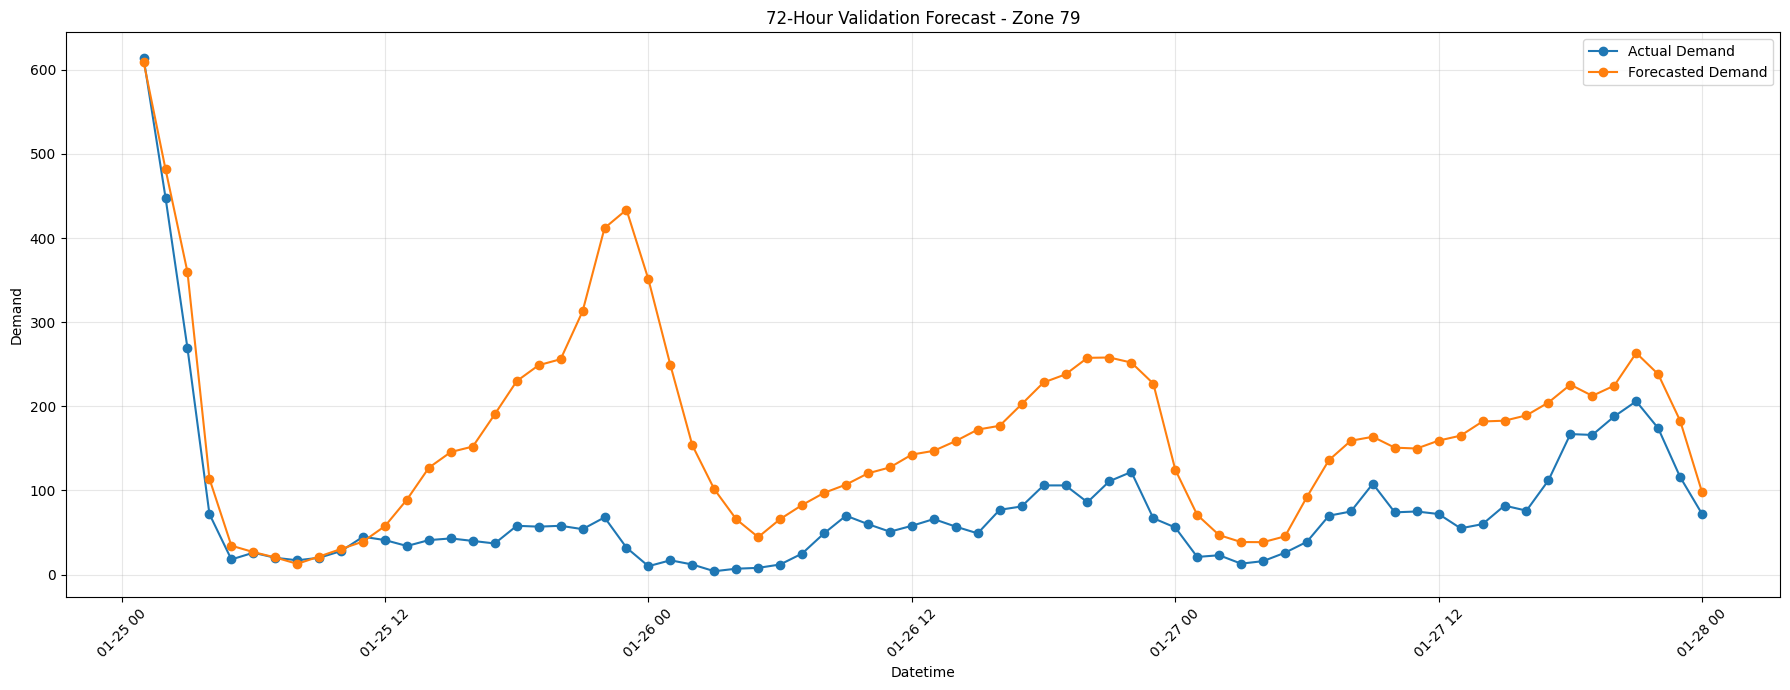

In [35]:

# Step 12: Compare Actual vs Forecasted Demand
plt.figure(
    figsize=(18,7)
)

plt.plot(

    forecast_results["hour"],

    forecast_results[
        "actual_demand"
    ],

    marker='o',

    label='Actual Demand'

)

plt.plot(

    forecast_results["hour"],

    forecast_results[
        "forecasted_demand"
    ],

    marker='o',

    label='Forecasted Demand'

)

plt.title(
    f"72-Hour Validation Forecast - Zone {zone_id}"
)

plt.xlabel(
    "Datetime"
)

plt.ylabel(
    "Demand"
)

plt.xticks(
    rotation=45
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

# Forecast Analysis and Reasons for Forecast Errors

## Observations

- The XGBoost model successfully generated forecasts for the entire 72-hour validation period using a recursive forecasting approach.
- The forecasted demand generally followed the overall trend of the actual demand series, indicating that the model captured the underlying temporal demand patterns.
- Major demand peaks and low-demand periods were identified; however, the forecasted values tended to overestimate actual demand.
- The difference between actual and forecasted demand increased gradually as the forecasting horizon progressed.
- This behavior suggests that forecasting performance deteriorates over extended horizons, which is common in recursive multi-step forecasting.

---

## Reasons for Forecast Differences

### 1. Limited Historical Training Data

- The model was trained using only **one month of historical taxi demand data (January 2026)**.
- This period contains approximately **four weekly demand cycles**, limiting the model's ability to learn stable and representative demand patterns.
- Additional historical data would expose the model to a wider variety of demand behaviors and improve generalization capability.

**Impact:** High

---

### 2. Recursive Forecasting Error Propagation

- The forecasting process employed a **recursive multi-step forecasting strategy**, where previous predictions were used to generate lag features for future predictions.
- Small errors introduced in early forecasting steps propagated through subsequent predictions.
- As forecasting moved further into the future, these accumulated errors resulted in larger deviations from actual demand values.

**Impact:** Very High

---

### 3. High Demand Variability

Validation demand statistics showed substantial fluctuations:

| Metric | Value |
|---------|--------|
| Mean Demand | 77.68 |
| Standard Deviation | 93.06 |
| Maximum Demand | 614 |

- The significant difference between average demand and peak demand indicates highly volatile demand patterns.
- Such variability increases forecasting complexity, particularly during peak demand periods.

**Impact:** High

---

### 4. Absence of External Influencing Factors

The forecasting model relied primarily on:

- Historical demand values
- Time-based features
- Lag features
- Rolling statistics

However, important external variables affecting taxi demand were not incorporated, including:

- Weather conditions
- Public holidays
- Special events
- Traffic disruptions
- Seasonal tourism activities

The exclusion of these factors limits the model's ability to capture sudden demand fluctuations.

**Impact:** Moderate to High

---

### 5. Limited Weekly Seasonal Information

- Weekly seasonal behavior was captured using features such as **lag_168**.
- However, with only one month of data, the model observed approximately **four instances of each weekday pattern**.
- This limited exposure restricts the model's ability to robustly learn weekly seasonality.

**Impact:** Moderate

---

### 6. Extended Forecast Horizon

- The model generated forecasts for a **72-hour (3-day) horizon**.
- Forecast uncertainty naturally increases as the prediction horizon extends further into the future.
- Multi-step forecasting is inherently more challenging than one-step forecasting because future observations are unavailable during prediction.

**Impact:** Moderate

---

## Error Metric Interpretation

| Metric | Value |
|---------|--------|
| Validation Forecast MAE | 91.87 |
| Validation Forecast RMSE | 121.27 |

### Interpretation

- The model's forecasts deviated from actual demand by approximately **92 trips per hour on average**.
- The higher RMSE compared to MAE suggests the presence of several larger forecasting errors.
- These larger errors likely occurred during periods of high demand volatility and peak demand spikes.

---

## Overall Assessment

- The XGBoost model successfully captured the general temporal structure and demand trends within the validation period.
- Forecast accuracy decreased over longer forecasting horizons due to recursive error accumulation.
- Demand overestimation was observed throughout the validation period, indicating limitations in long-term recursive forecasting performance.
- Despite these limitations, the experiment provided valuable insights into the practical challenges associated with real-world taxi demand forecasting.

---

# Final Summary

The differences between actual and forecasted demand primarily resulted from limited historical training data, recursive forecasting error propagation, high demand variability, and the absence of external explanatory variables influencing taxi demand. Although forecasting accuracy declined over the 72-hour horizon, the model effectively captured overall demand patterns and validated the end-to-end forecasting framework under realistic operational conditions. These findings highlight both the strengths and limitations of recursive multi-step forecasting for taxi demand prediction.

---

In [36]:
forecast_results.to_csv(

    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/Yellow_Dataset/results/validation_forecast_results.csv",

    index=False

)

print(
    "Validation forecast results saved successfully."
)

Validation forecast results saved successfully.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
df = pd.read_parquet(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/Yellow_Dataset/data/feature_engineered_demand.parquet"
)

## Step 3: Zone Selection Strategy

Since the dataset contains multiple NYC taxi zones, a single-zone forecasting approach was adopted.

The taxi zone with the highest number of observations was selected to ensure:

- Sufficient training samples
- More stable demand patterns
- Reliable lag feature generation
- Improved recursive forecasting performance
- Reduced model complexity

In [4]:
# Count observations for each zone
zone_counts = (
    df.groupby("PULocationID")
    .size()
    .sort_values(ascending=False)
)

# Select the zone with maximum observations
zone_id = zone_counts.index[0]

print(
    "Selected Zone:",
    zone_id
)

print(
    "Total Observations:",
    zone_counts.iloc[0]
)

Selected Zone: 79
Total Observations: 577


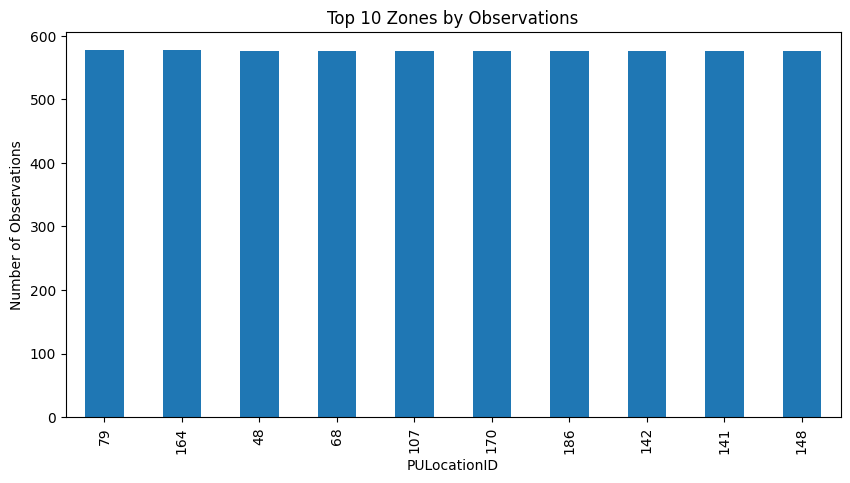

In [5]:
zone_counts.head(10).plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Zones by Observations"
)

plt.ylabel(
    "Number of Observations"
)

plt.show()

In [15]:
train = zone_df.iloc[:-168]

validation = zone_df.iloc[-168:-96]

test = zone_df.iloc[-96:]

In [17]:
zone_data = zone_df.iloc[:-1]

In [19]:
hourly_df = pd.read_parquet(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/Yellow_Dataset/data/hourly_demand.parquet"
)

zone_df = (
    hourly_df[
        hourly_df["PULocationID"] == 79
    ]
    .sort_values("hour")
    .reset_index(drop=True)
)

# Remove potentially incomplete final record
zone_df = zone_df.iloc[:-1]

print(
    "Deployment Data Shape:",
    zone_data.shape
)

print(
    "Latest Demand Value:",
    zone_df["demand"].iloc[-1]
)

Deployment Data Shape: (576, 14)
Latest Demand Value: 732
